Süper! Şimdi geldik sınıflandırma algoritmalarının en güçlülerinden biri olan:

---

# 🟥 Support Vector Machine (SVM)

## (Türkçesi: Destek Vektör Makinesi)

---

## 📌 Tanım:

SVM, sınıflar arasındaki **en iyi ayrım çizgisini** (decision boundary) bulmaya çalışan bir sınıflandırma algoritmasıdır.

> Amaç:
> "İki sınıfı ayıran **maksimum marjlı (maksimum boşluklu)** doğruyu (ya da düzlemi) bul."

---

## 🧠 Temel Mantık:

SVM şöyle düşünür:

* “İki sınıfı birbirinden ayıran birçok çizgi olabilir…”
* “Ama ben **en güvenli** olanı seçmek istiyorum.”
* Yani: **Sınıflara en yakın noktalarla (destek vektörleriyle) olan mesafeyi maksimum yapacak** doğruyu bulmak.

### 📈 2D’de örnek:

```
Sınıf 0: ●●●
Sınıf 1: ○○○

Amaç: ● ve ○’ları ayıran ve bu iki gruba **en uzakta kalan** çizgiyi bulmak.
```

---

## 📊 Özetle:

SVM'in amacı:

* Sınıfları **olabildiğince net** ayır
* **Margin (boşluk)** büyük olsun
* Sınıra en yakın olanlara destek ver → "support vectors"

---

## ✅ Ne Zaman Çok İyidir?

* Verilerin **doğrusal olarak ayrılabilir** olduğu durumlarda çok iyi sonuç verir.
* Özellikle **daha az sayıda gözlem, çok sayıda özellik** varsa mükemmel çalışır.

---

## ⚠️ Zayıf Olduğu Durumlar:

* Veri çok büyükse (örneğin 100.000+ gözlem) → SVM yavaş çalışabilir
* Özellikler iyi ölçeklenmemişse (feature scaling yapılmazsa) → Performans düşer

---

## 🧮 SVM’de Karar Sınırı Neye Göre Belirlenir?

Karar çizgisi şu formülle temsil edilir:

```
w·x + b = 0
```

* `w`: ağırlık vektörü
* `x`: giriş verisi
* `b`: bias

Sınıflar:

* `w·x + b > 0` → Sınıf 1
* `w·x + b < 0` → Sınıf 0

Amaç:

> Bu çizgiyi öyle seç ki, çizgiye en yakın noktalara olan **mesafeler maksimum** olsun.

---

## 🧪 Basit Örnek:

Diyelim ki:

| X1 | X2 | Sınıf |
| -- | -- | ----- |
| 2  | 4  | 0     |
| 4  | 2  | 0     |
| 6  | 6  | 1     |
| 8  | 8  | 1     |

Burada sınıf 0 ve 1 oldukça güzel ayrılıyor. SVM bu iki grubun arasına bir **doğru** koyar ve en yakın ● ve ○’ya olan **marjı maksimize eder**.

---

## 💻 Python Örneği:

```python
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Veri ölçeklenmeli
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

# SVM modeli
svm = SVC(kernel='linear')
svm.fit(X_train_scaled, y_train)

y_pred = svm.predict(X_test_scaled)
```

---

## 🔍 Neden `kernel='linear'`?

Çünkü bu aşamada **doğrusal (linear)** ayrılabilirlik öğretiliyor.
Sonraki adımda (Kernel SVM) **doğrusal olmayan veriler** için çekirdek fonksiyonları gelecek (örneğin RBF kernel).

---

## 🎯 SVM vs K-NN vs Logistic Regression

| Özellik            | Logistic Regression | KNN            | SVM (Linear)               |
| ------------------ | ------------------- | -------------- | -------------------------- |
| Karar yapısı       | Olasılık tahmini    | Komşulara göre | Marj maksimize eden çizgi  |
| Eğitim zamanı      | Hızlı               | Eğitim yok     | Orta                       |
| Tahmin zamanı      | Hızlı               | Yavaş          | Orta                       |
| Karmaşık verilerde | Zayıf               | Esnek          | Kernel eklenince çok güçlü |

---

## 🎓 Özetle:

* **SVM**, sınıflar arasındaki en iyi ayrımı yapan doğruyu (ya da düzlemi) bulur.
* Özellikle **doğrusal ayrılabilirlik** varsa çok güçlüdür.
* Her veri için **karar çizgisine olan uzaklığı** değerlendirir.
* **Destek vektörleri**, modelin kararını etkileyen en kritik noktalardır.

---

Video sonrası birlikte çizgi çizip destek vektörleri görselleştirebiliriz.
Bir sonraki konu **Kernel SVM** olacak. Ona geçince daha da esnek modellerle tanışacaksın. Hazırsan oraya da geçelim!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset = pd.read_csv('Social_Network_Ads.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [4]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Training the SVM model on the Training set

In [5]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'linear', random_state = 0)
classifier.fit(X_train, y_train)

SVC(kernel='linear', random_state=0)

In [6]:
print(classifier.predict(sc.transform([[30,87000]])))

[0]


In [7]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [1 1]
 [1 1]]


In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[66  2]
 [ 8 24]]


0.9

## Visualising the Training set results
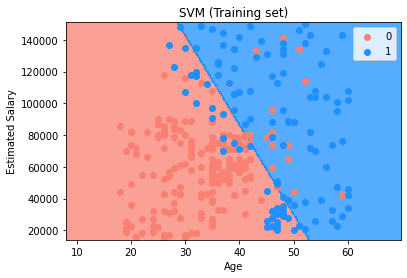

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('SVM (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

## Visualising the Test set results
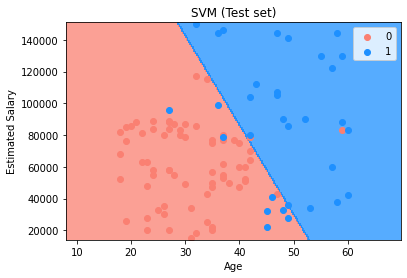

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('SVM (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()